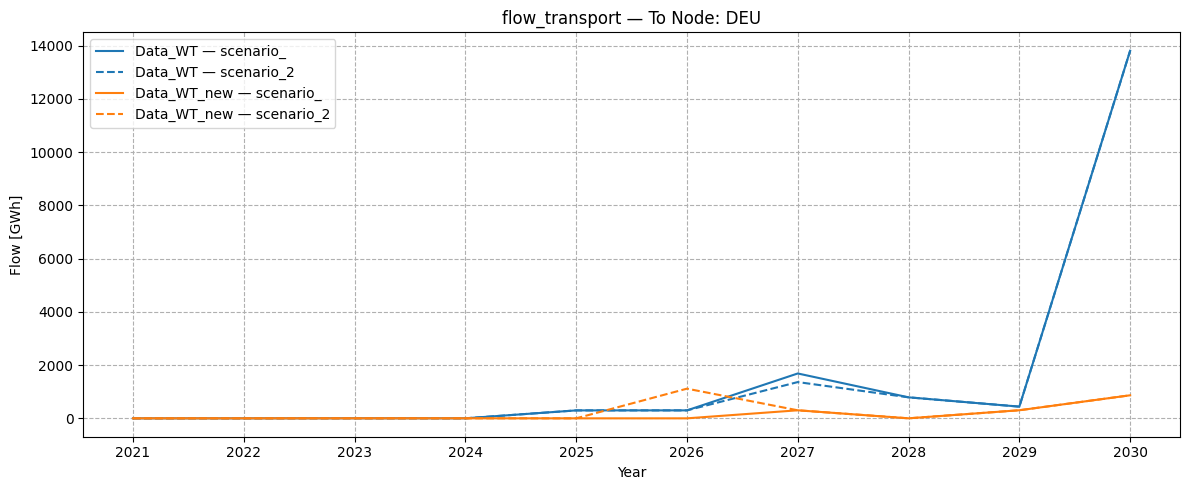

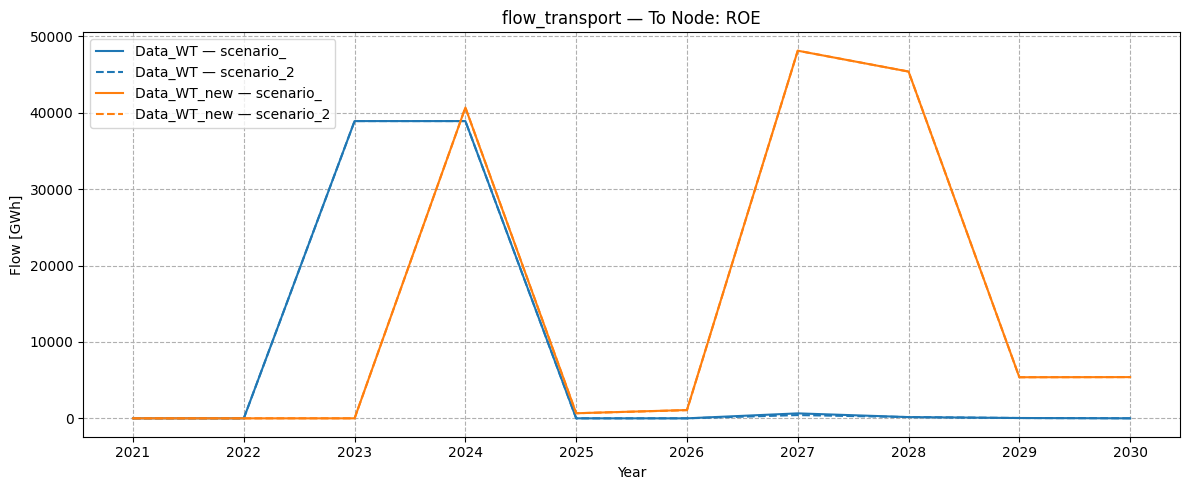

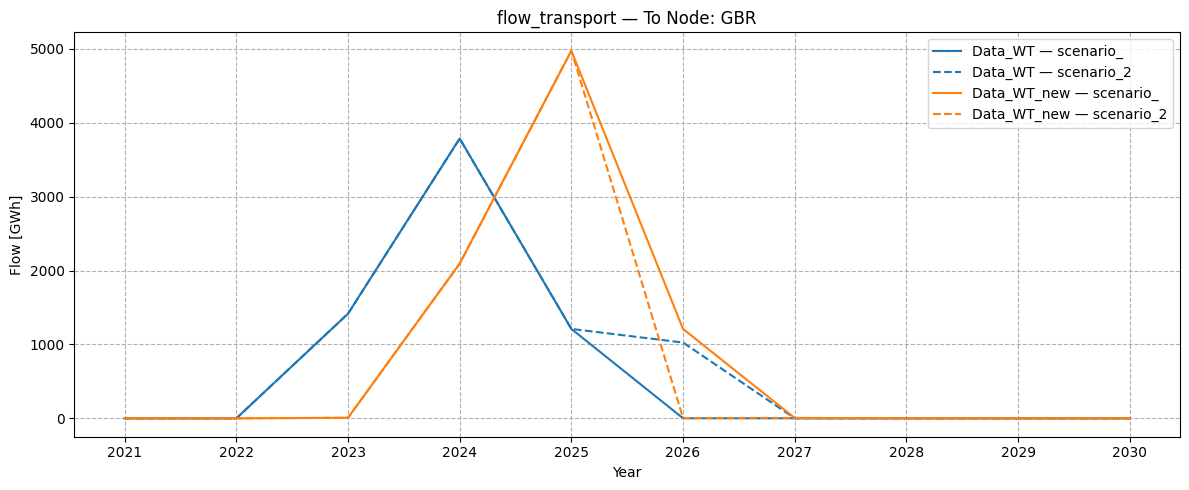

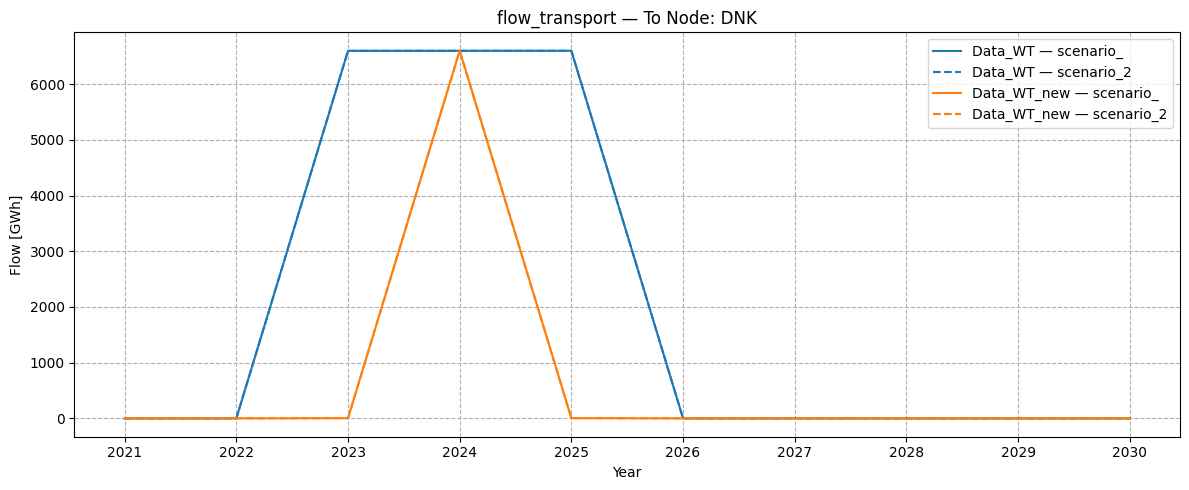

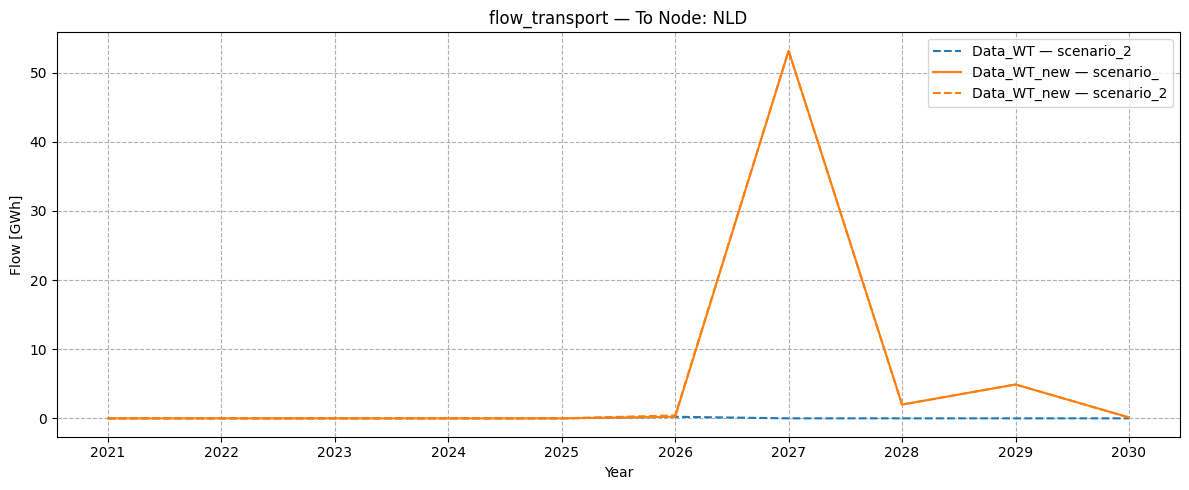

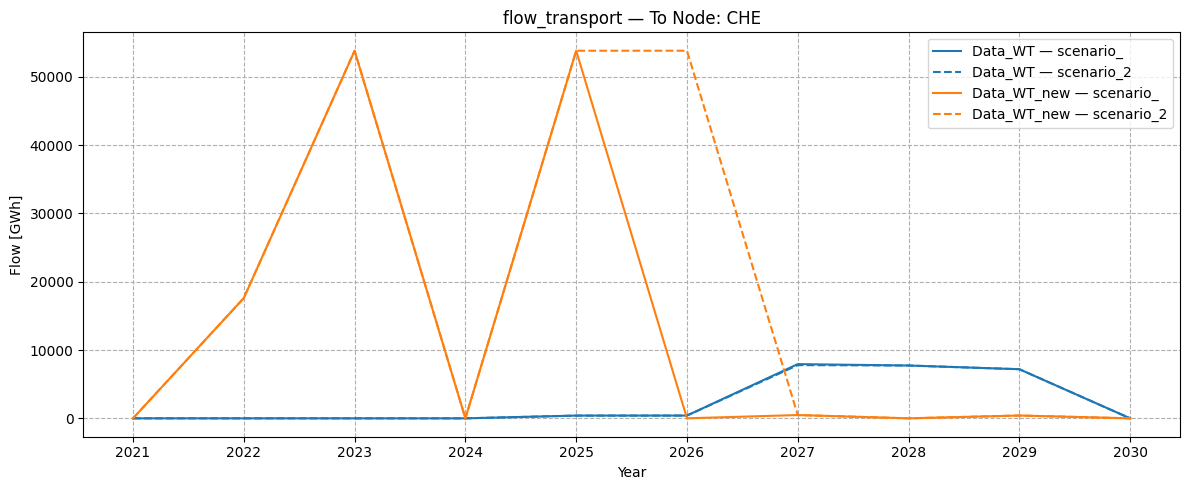

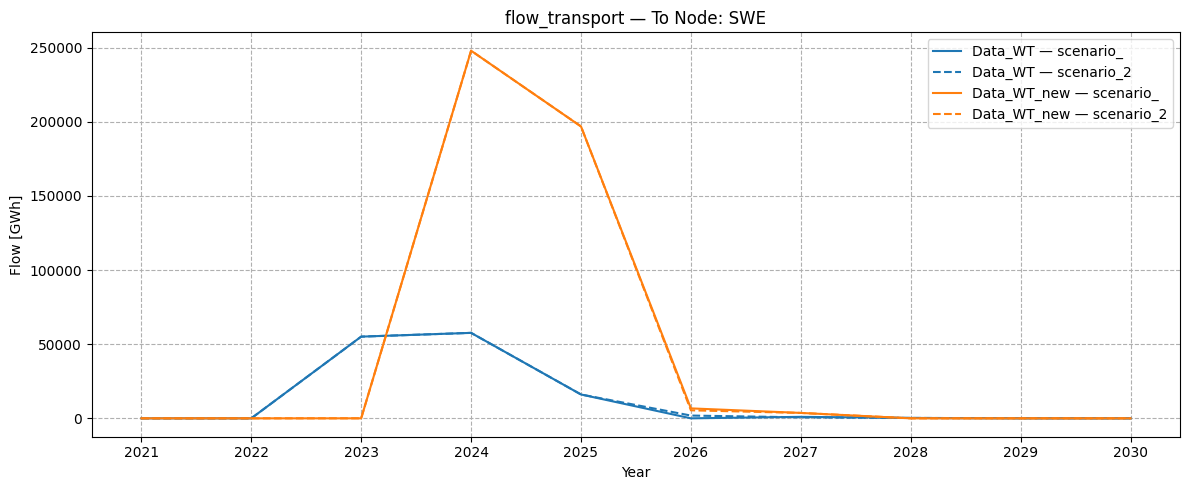

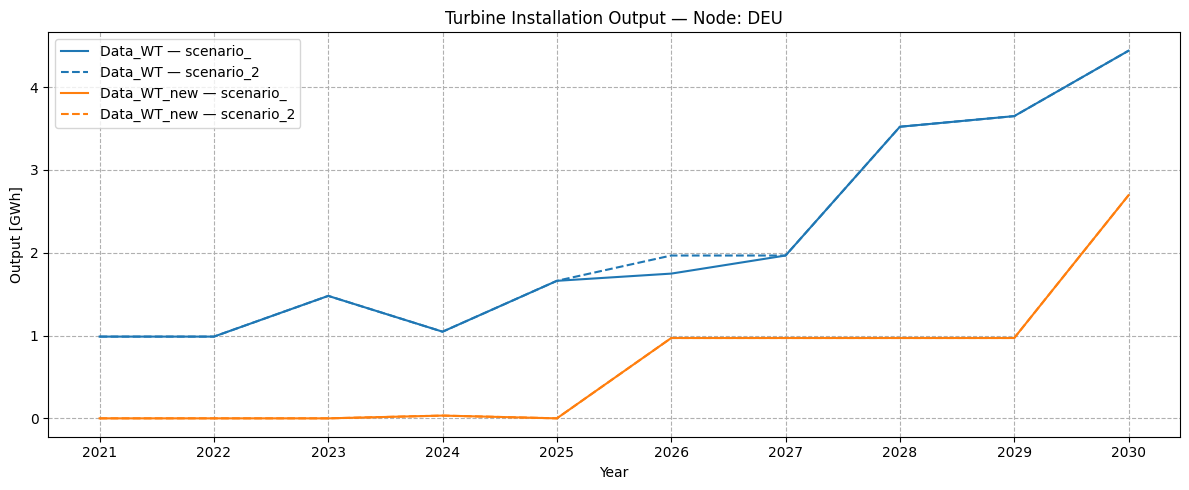

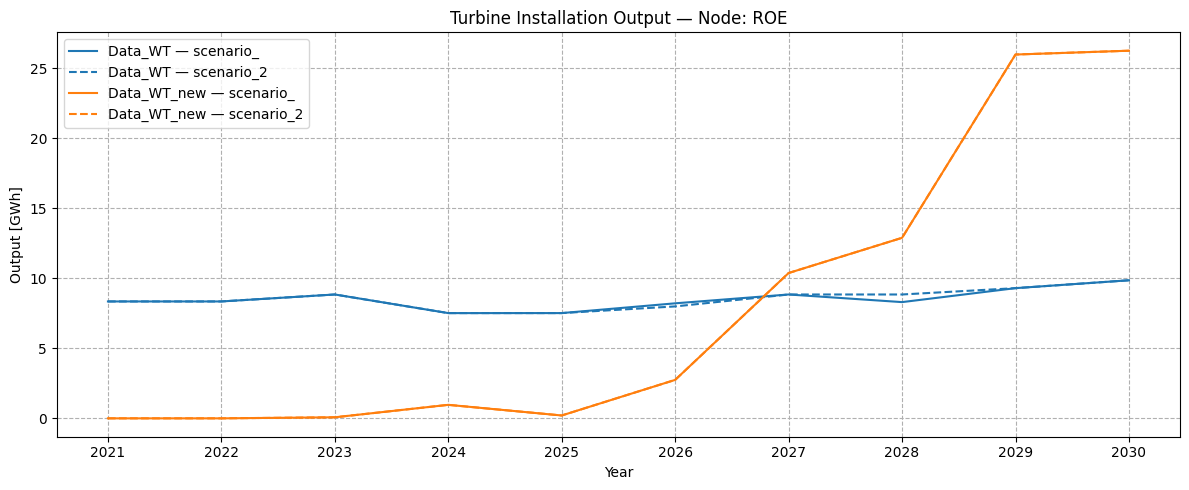

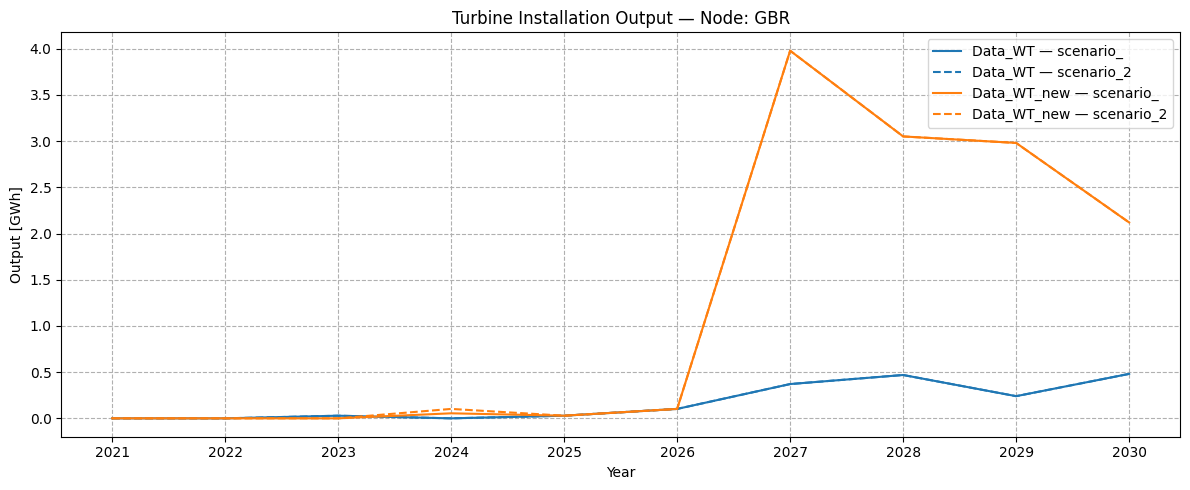

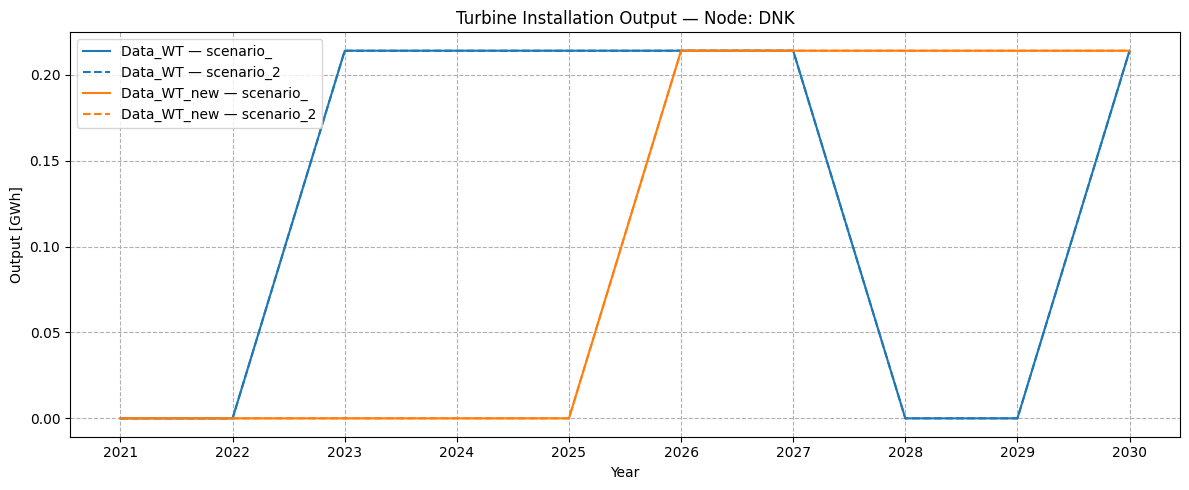

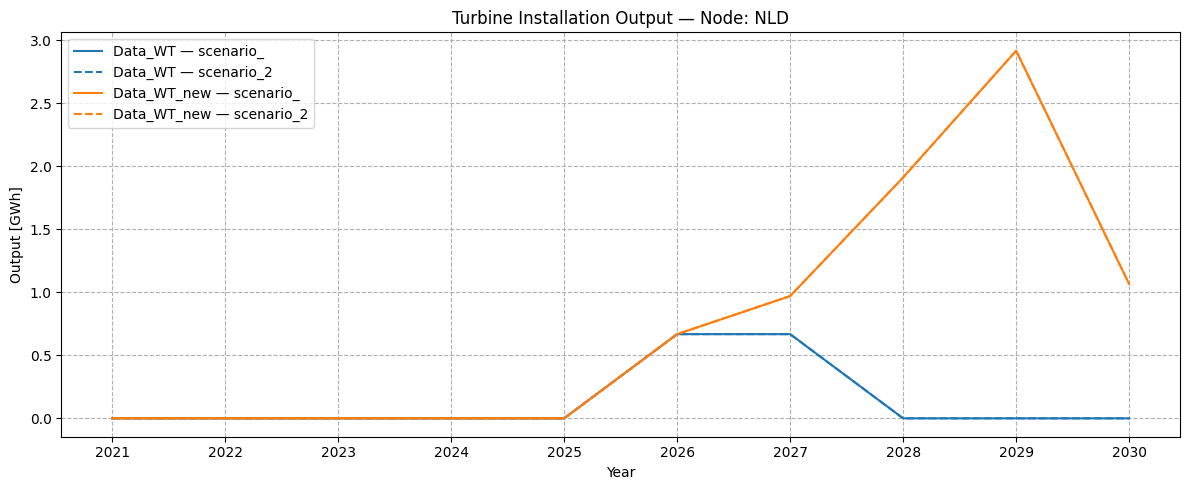

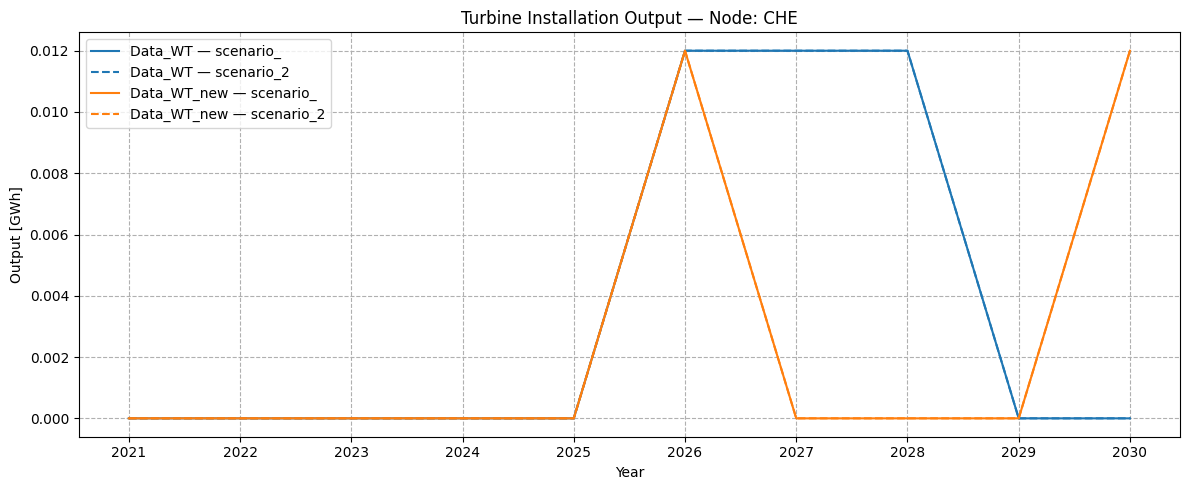

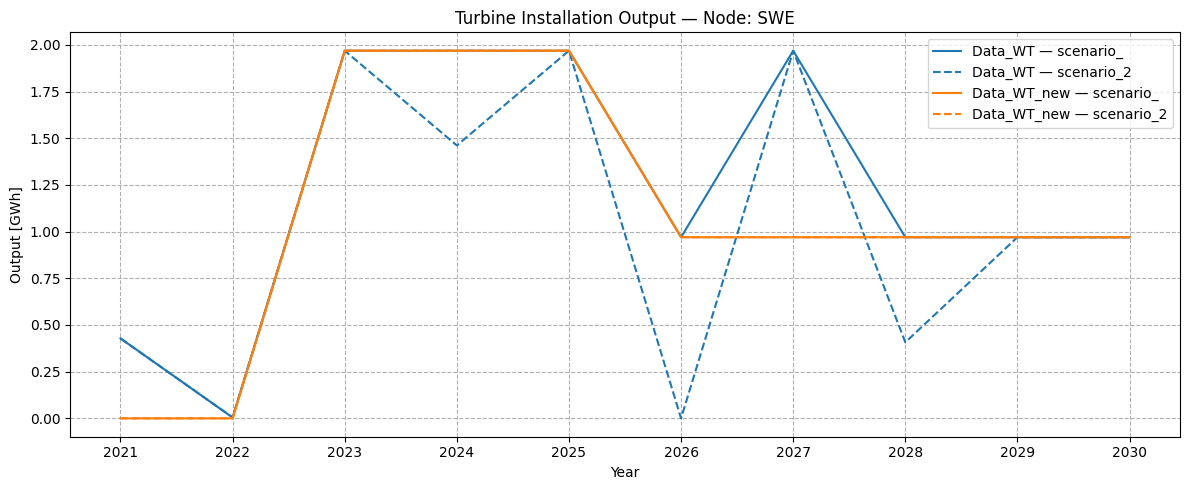

In [10]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
dataset_name_1 = 'Data_WT'
dataset_name_2 = 'Data_WT_new'
output_path_1 = os.path.join("outputs", dataset_name_1)
output_path_2 = os.path.join("outputs", dataset_name_2)
r1 = Results(output_path_1)
r2 = Results(output_path_2)

variables = ['flow_transport', 'flow_conversion_output']
target_nodes = {"CHE", "DEU", "DNK", "GBR", "NLD", "ROE", "SWE"}
target_scenarios = ["scenario_", "scenario_2"]

dataset_colors = {
    dataset_name_1: 'tab:blue',
    dataset_name_2: 'tab:orange'
}

scenario_styles = {
    "scenario_": '-',
    "scenario_2": '--'
}


def plot_flow_transport(df1_raw, df2_raw):
    df1_raw.index.set_names(['scenario'] + df1_raw.index.names[1:], inplace=True)
    df2_raw.index.set_names(['scenario'] + df2_raw.index.names[1:], inplace=True)

    df1 = df1_raw.reset_index()
    df2 = df2_raw.reset_index()

    time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

    # Keep only flows going to target nodes
    df1 = df1[df1["scenario"].isin(target_scenarios) & df1["edge"].str.split("-").str[1].isin(target_nodes)]
    df2 = df2[df2["scenario"].isin(target_scenarios) & df2["edge"].str.split("-").str[1].isin(target_nodes)]

    for node in target_nodes:
        plt.figure(figsize=(12, 5))
        has_data = False

        for dataset_name, df in zip([dataset_name_1, dataset_name_2], [df1, df2]):
            df_sub = df[df["edge"].str.endswith(f"-{node}")]
            for scenario in target_scenarios:
                df_scenario = df_sub[df_sub["scenario"] == scenario]
                if df_scenario.empty:
                    continue
                series = df_scenario[time_cols].sum()
                if not np.allclose(series, 0):
                    has_data = True
                    plt.plot(
                        time_cols,
                        series,
                        label=f"{dataset_name} — {scenario}",
                        color=dataset_colors[dataset_name],
                        linestyle=scenario_styles[scenario]
                    )

        if has_data:
            plt.title(f"flow_transport — To Node: {node}")
            plt.xlabel("Year")
            plt.ylabel("Flow [GWh]")
            plt.xticks(time_cols, labels=[str(2021 + i) for i in range(len(time_cols))])
            plt.grid(True, linestyle="--")
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            plt.close()


def plot_flow_conversion_output(df1_raw, df2_raw):
    df1_raw.index.set_names(['scenario'] + df1_raw.index.names[1:], inplace=True)
    df2_raw.index.set_names(['scenario'] + df2_raw.index.names[1:], inplace=True)

    df1 = df1_raw.reset_index()
    df2 = df2_raw.reset_index()

    time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

    # ✅ Filter to only "Turbine_Installation" and target nodes
    df1 = df1[
        (df1["scenario"].isin(target_scenarios)) &
        (df1["node"].isin(target_nodes)) &
        (df1["technology"] == "Turbine_Installation")
    ]
    df2 = df2[
        (df2["scenario"].isin(target_scenarios)) &
        (df2["node"].isin(target_nodes)) &
        (df2["technology"] == "Turbine_Installation")
    ]

    for node in target_nodes:
        plt.figure(figsize=(12, 5))
        has_data = False

        for dataset_name, df in zip([dataset_name_1, dataset_name_2], [df1, df2]):
            df_sub = df[df["node"] == node]
            for scenario in target_scenarios:
                df_scenario = df_sub[df_sub["scenario"] == scenario]
                if df_scenario.empty:
                    continue
                series = df_scenario[time_cols].sum()
                if not np.allclose(series, 0):
                    has_data = True
                    plt.plot(
                        time_cols,
                        series,
                        label=f"{dataset_name} — {scenario}",
                        color=dataset_colors[dataset_name],
                        linestyle=scenario_styles[scenario]
                    )

        if has_data:
            plt.title(f"Turbine Installation Output — Node: {node}")
            plt.xlabel("Year")
            plt.ylabel("Output [GWh]")
            plt.xticks(time_cols, labels=[str(2021 + i) for i in range(len(time_cols))])
            plt.grid(True, linestyle="--")
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            plt.close()

# === Run Plots
try:
    plot_flow_transport(r1.get_full_ts('flow_transport'), r2.get_full_ts('flow_transport'))
    plot_flow_conversion_output(r1.get_full_ts('flow_conversion_output'), r2.get_full_ts('flow_conversion_output'))
except Exception as e:
    print(f"⚠️ Error: {e}")


In [9]:
unit = r1.get_unit('flow_transport')
unit

technology
Aluminium_transport            GW * h
Bauxite_transport              GW * h
Blade_transport                GW * h
Carbon_Fiber_transport         GW * h
Concrete_transport             GW * h
Copper_Ore_transport           GW * h
Copper_transport               GW * h
Iron_Ore_transport             GW * h
Limestone_transport            GW * h
Nacelle_transport              GW * h
Oil_transport                  GW * h
Permanent_Magnets_transport    GW * h
REE_Ore_transport              GW * h
REE_transport                  GW * h
Steel_transport                GW * h
Tower_transport                GW * h
Turbine_transport              GW * h
Name: units, dtype: object